Center (mean): 21189.07
Sigma (std):   3920.02
Display range: [19229.06, 23149.08]  (center ± 0.5·sigma)
Total width:   1.00·sigma


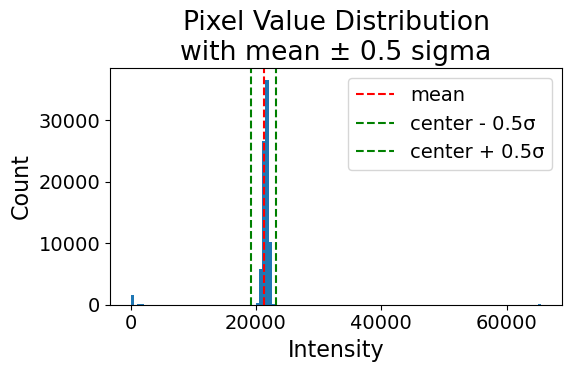

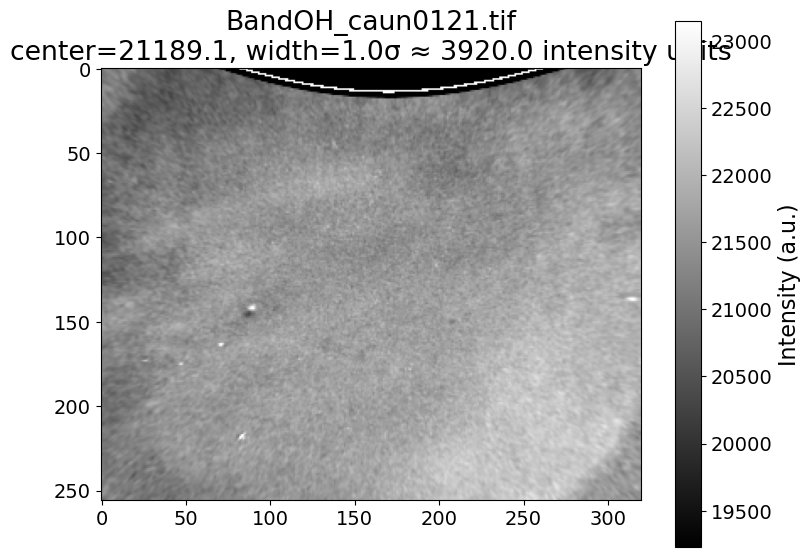

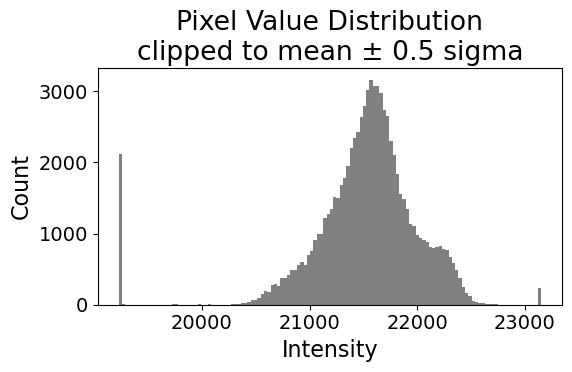

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff

path = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150\TempOH_caun1176.tif"

img = tiff.imread(path)  # uint16, (256, 320)
arr = img.astype(np.float32)  # safer for statistics and normalization

# Flatten for statistics
sample = arr.ravel()

# Basic statistics
center = float(np.mean(sample))
sigma = float(np.std(sample))

# Use a range with total width 1.4 sigma (center ± 0.7 sigma)
factor = 0.5
vmin = center - factor * sigma
vmax = center + factor * sigma

print(f"Center (mean): {center:.2f}")
print(f"Sigma (std):   {sigma:.2f}")
print(f"Display range: [{vmin:.2f}, {vmax:.2f}]  (center ± {factor}·sigma)")
print(f"Total width:   {2*factor:.2f}·sigma")

# Histogram of raw data
plt.figure(figsize=(6, 4))
plt.hist(sample, bins=128)
plt.axvline(center, color="r", linestyle="--", label="mean")
plt.axvline(vmin, color="g", linestyle="--", label=f"center - {factor}σ")
plt.axvline(vmax, color="g", linestyle="--", label=f"center + {factor}σ")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title(f"Pixel Value Distribution\nwith mean ± {factor} sigma")
plt.legend()
plt.tight_layout()
plt.show()
plt.close()

# Image using mean ± 0.7 sigma for display
plt.figure(figsize=(8, 6))
plt.imshow(np.clip(arr, vmin, vmax), cmap="gray", vmin=vmin, vmax=vmax)
plt.colorbar(label="Intensity (a.u.)")
plt.title(
    "BandOH_caun0121.tif\n"
    f"center={center:.1f}, width={2*factor:.1f}σ ≈ {2*factor*sigma:.1f} intensity units"
)
plt.tight_layout()
plt.show()
plt.close()

# Histogram of data clipped to mean ± 0.7 sigma
cleaned = np.clip(arr, vmin, vmax).ravel()

plt.figure(figsize=(6, 4))
plt.hist(cleaned, bins=128, color="gray")
plt.xlabel("Intensity")
plt.ylabel("Count")
plt.title(f"Pixel Value Distribution\nclipped to mean ± {factor} sigma")
plt.tight_layout()
plt.show()
plt.close()


Center (mean): 21546.36
Sigma (std):   326.01
Dynamic range: [20242.33, 22850.40] = mean ± 4.00·sigma
In-range count: 52772
In-range min/max: 20272.00 / 22822.00
In-range mean/std: 21546.06 / 324.95
In-range percentiles 5/50/95: 20981.55 / 21561.00 / 22089.00


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.38390045674229517 idx= (np.int64(2), np.int64(10), np.int64(77), np.int64(126))
selected elements: 16755
------------
cluster= 1
amplitude= 0.3646103497935669 idx= (np.int64(4), np.int64(7), np.int64(76), np.int64(124))
selected elements: 1740
------------
cluster= 2
amplitude= 0.35739528092738937 idx= (np.int64(16), np.int64(6), np.int64(36), np.int64(106))
selected elements: 58856
------------
cluster= 3
amplitude= 0.34432209261674407 idx= (np.int64(20), np.int64(7), np.int64(74), np.int64(59))
selected elements: 101613
------------
cluster= 4
amplitude= 0.3392875687639353 idx= (np.int64(8), np.int64(9), np.int64(29), np.int64(144))
selected elements: 10828
------------
cluster= 5
amplitude= 0.29972985012642406 idx= (np.int64(24), np.int64(10), np.int64(121), np.int64(52))
selected elements: 102694
------------
cluster= 6
amplitude= 0.2908604252171261 idx= (np.int64(21), np.int64(6), np.int64(77), np.int64(131))
selected elements: 29489
----------

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 70.00it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


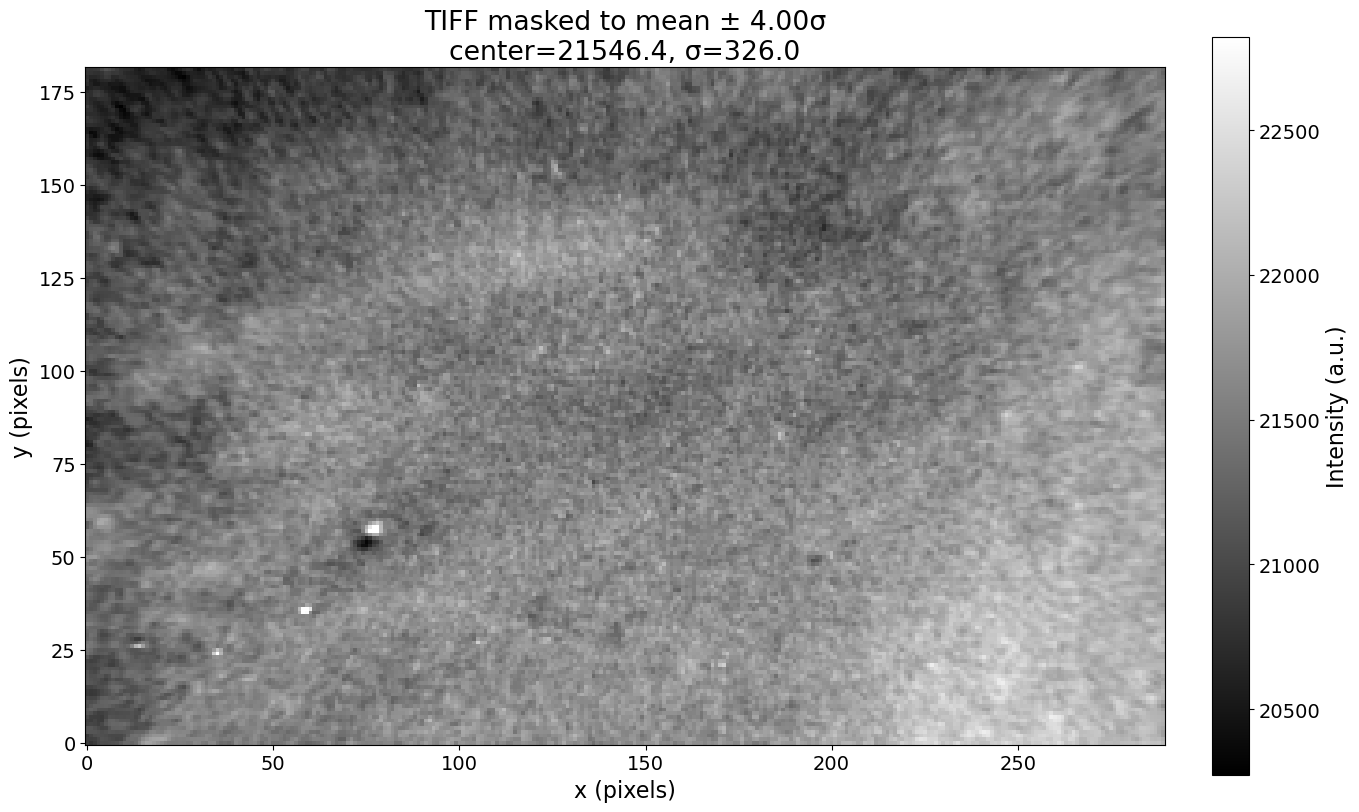

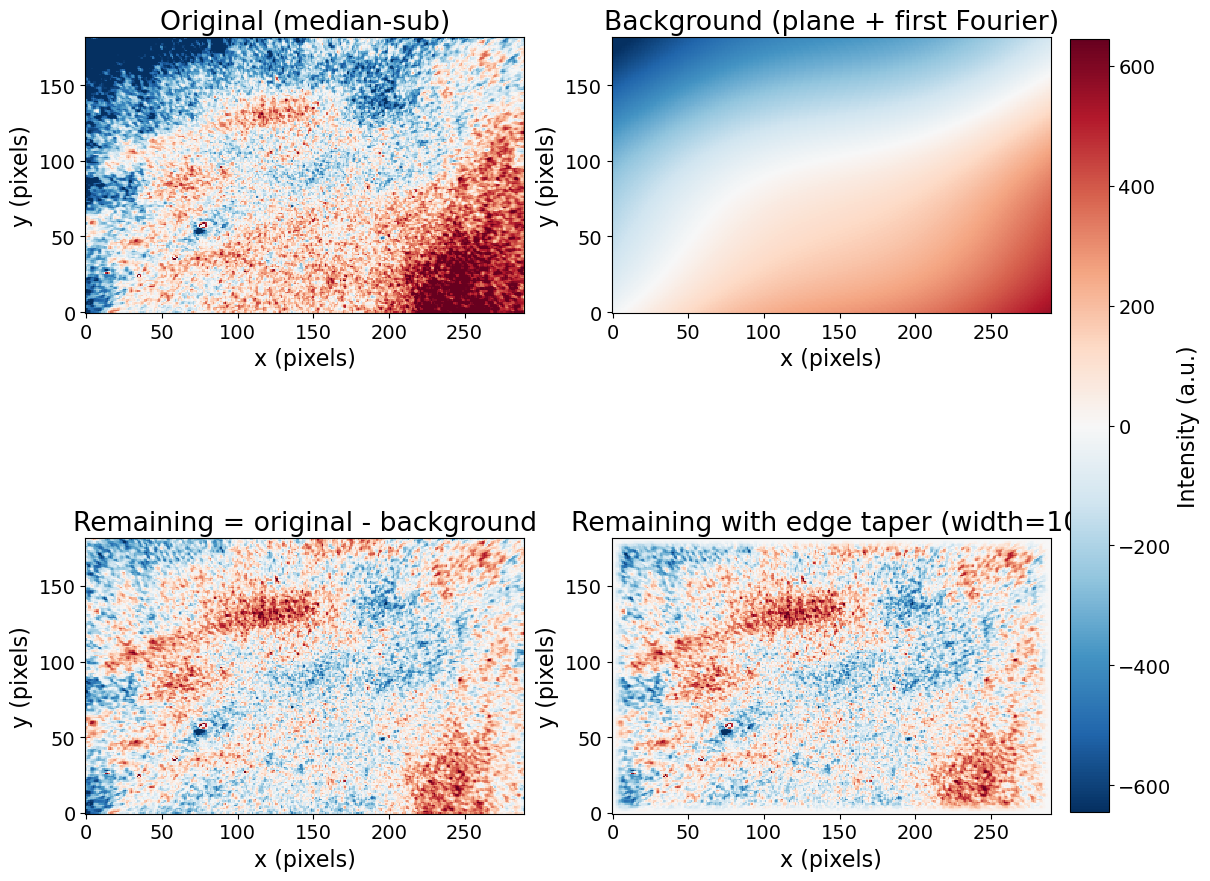

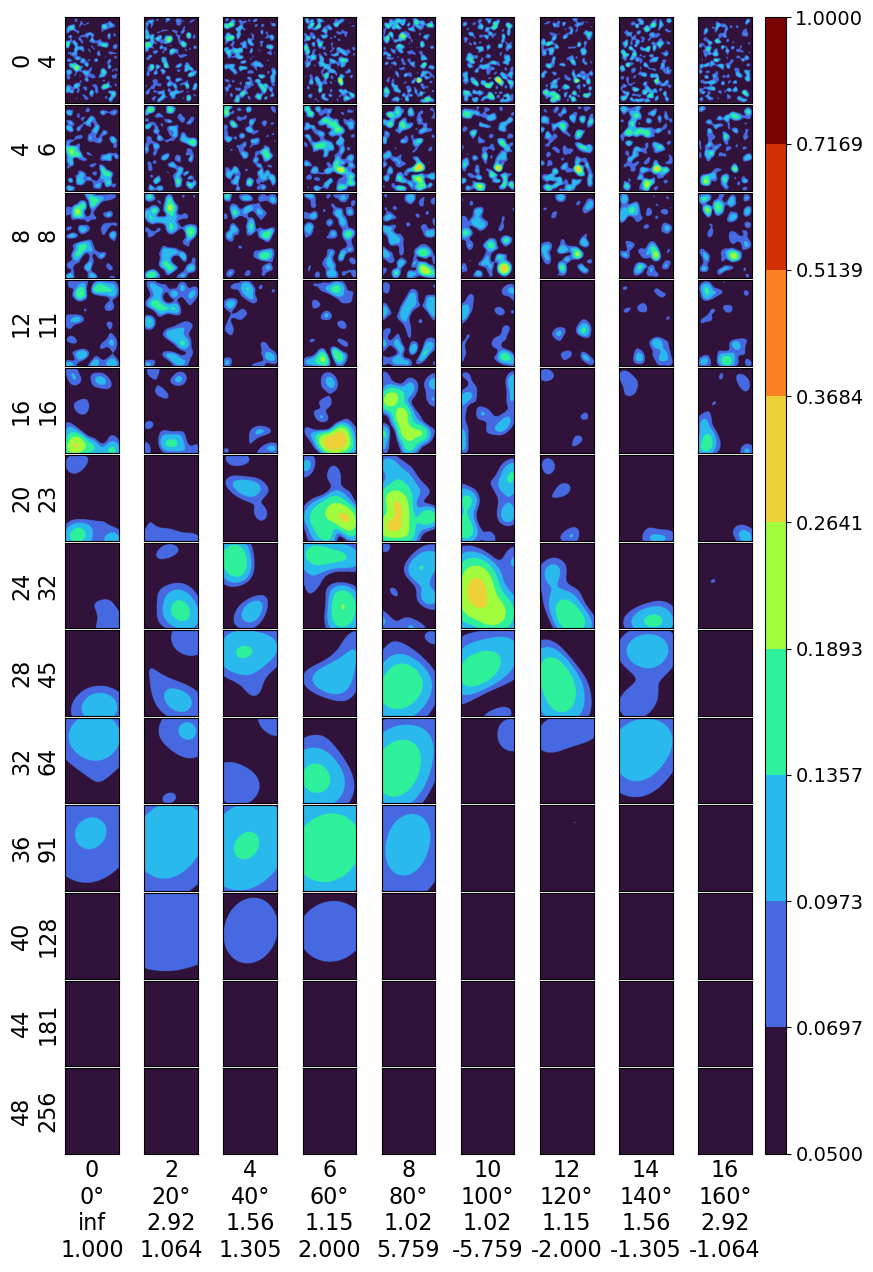

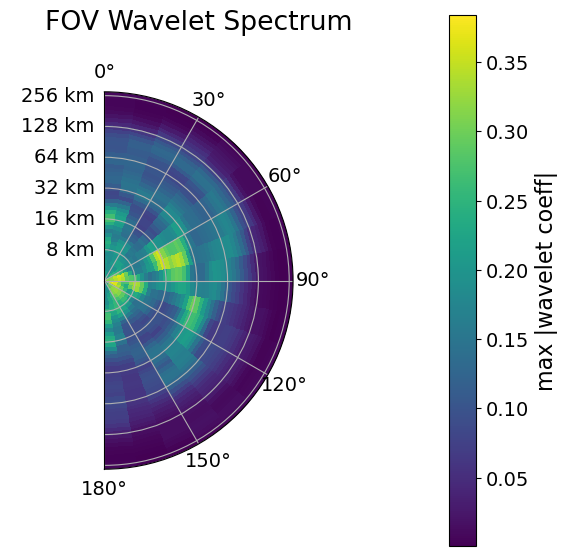

Cluster 0: amp=0.384, lamx=-27.39, lamy=4.83, lam=4.76
Cluster 1: amp=0.365, lamx=16.54, lamy=6.02, lam=5.66
Cluster 2: amp=0.357, lamx=32.00, lamy=18.48, lam=16.00
Cluster 3: amp=0.344, lamx=66.16, lamy=24.08, lam=22.63
Cluster 4: amp=0.339, lamx=130649914825562960.00, lamy=8.00, lam=8.00
Cluster 5: amp=0.300, lamx=-184.28, lamy=32.49, lam=32.00
Cluster 6: amp=0.291, lamx=49.35, lamy=28.49, lam=24.68
Cluster 7: amp=0.288, lamx=38.05, lamy=21.97, lam=19.03
Cluster 8: amp=0.270, lamx=-9.66, lamy=54.79, lam=9.51


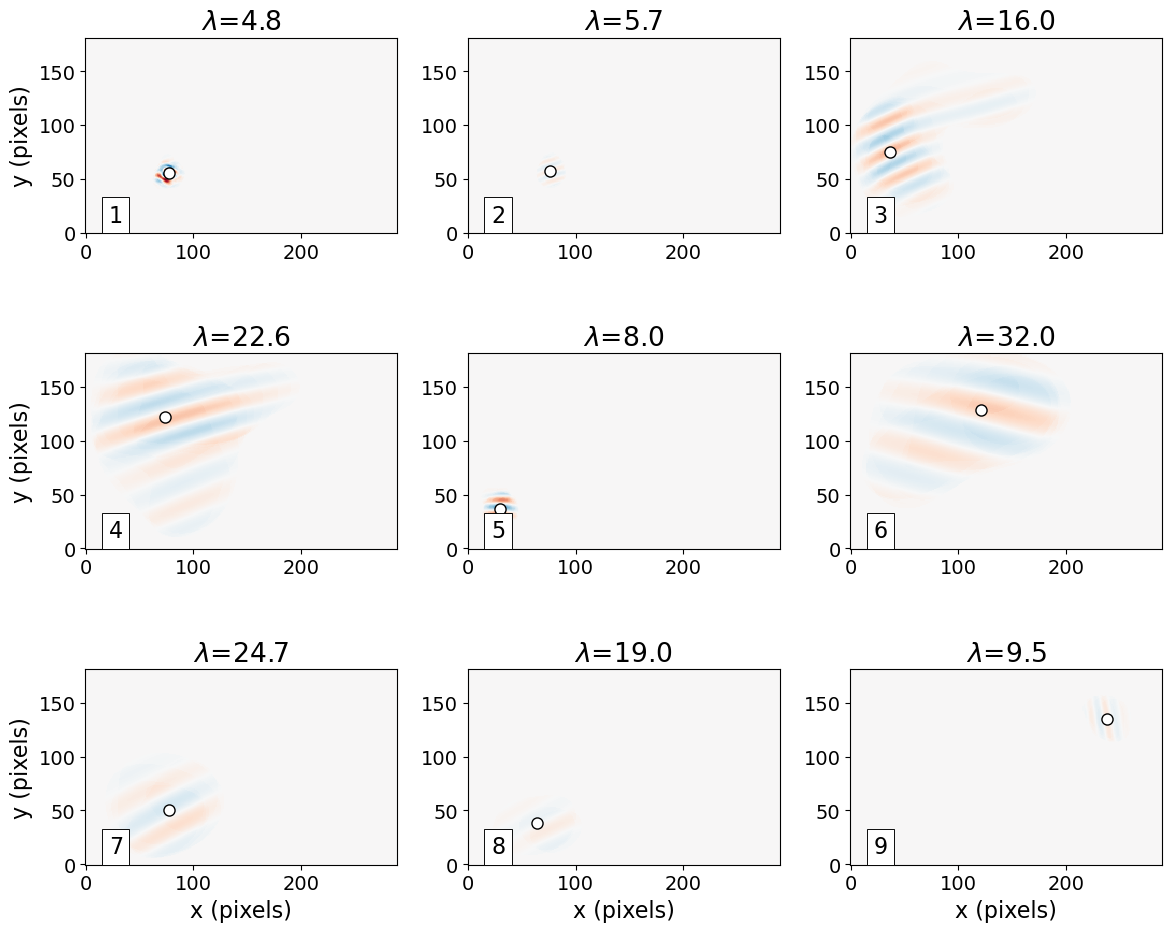

In [29]:
# Load a 16-bit TIFF, optionally mask values outside mean ± k·sigma for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   - masked/preview image
#   - original (median-sub), background (plane + first Fourier), remaining, tapered-remaining
#   - preprocessed-for-CWT
#   - FOV wavelet spectrum
#   - 9 largest wave clusters

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150\TempOH_caun1176.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 302)
Y_SLICE: Optional[slice] = slice(18, 200)

# Range filter: use mean ± k·sigma instead of fixed [6000, 10000]
APPLY_RANGE_FILTER = True
RANGE_SIGMA_FACTOR = 4   # k in mean ± k·sigma

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True        # include 2D plane in "background"
STANDARDIZE = True         # z-score remaining field before CWT
GAUSS_BLUR_SIGMA = 1     # 0 disables, else e.g., 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10     # width of tapered region near each edge (in pixels)

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook_pcolor(
    x1d: np.ndarray,
    y1d: np.ndarray,
    Z: np.ndarray,
    title: str,
    cmap="gray",
    vmin: float = None,
    vmax: float = None,
) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


# --------------------------
# Edge-taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    # cosine ramp from 0 to 1
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      - interior stays ~1
      - transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)
    # Flip y to compare easier
    y1d = y1d[::-1]

    # 2) Compute mean/std and dynamic range: mean ± k·sigma
    sample = raw.ravel().astype(float)
    center = float(np.mean(sample))
    sigma = float(np.std(sample))
    k = RANGE_SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"Center (mean): {center:.2f}")
    print(f"Sigma (std):   {sigma:.2f}")
    print(f"Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Range filter for preview
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"In-range min/max: {np.nanmin(vals):.2f} / {np.nanmax(vals):.2f}")
            print(f"In-range mean/std: {np.nanmean(vals):.2f} / {np.nanstd(vals):.2f}")
            p5, p50, p95 = np.nanpercentile(vals, [5, 50, 95])
            print(f"In-range percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within mean ± k·sigma")

        disp = np.clip(preview, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )
    else:
        disp = np.clip(raw, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF raw, display mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )

    # 4) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # 5) Background separation: plane + first Fourier
    proc0 = filled.copy()
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 6) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Compute global vmin/vmax for original / background / remaining / tapered-remaining
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered

    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 7) 4-panel background figure: original / background / remaining / tapered-remaining
    # 4-panel background figure (shared colorbar)
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10),
                                  constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()
    
    imgs_bg = [
        (orig_c, "Original (median-sub)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, f"Remaining with edge taper (width={TAPER_EDGE_PIXELS})"),
    ]
    
    # Draw first image, keep handle for colorbar
    im = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")
    
    # ONE colorbar for all 4 axes
    cbar = fig_bg.colorbar(im, ax=axs_bg, orientation="vertical",
                           fraction=0.04, pad=0.02)
    cbar.set_label("Intensity (a.u.)")


    # 8) Continue preprocessing on the tapered remaining field (for CWT only)
    proc = remaining_tapered.copy()
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        # proc = (proc - m) / s if s > 0 else (proc - m)
        proc = proc / np.std(proc) # Already subtracted median before. 
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 9) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.2)

    decomposition = cwt["decomposition"]
    orig = decomposition.copy()

    # 10) Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2, cmap=cmap, norm=norm)

    # 11) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # 12) Component panels: 9 largest clusters
    fig2, axs = plt.subplots(3, 3, figsize=(12, 10))
    axes_flat = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -.8, "vmax": .8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]            # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"$\lambda_x$={_fmt(lamx)}  "
                #rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            ax.set_aspect("equal", adjustable="box")

            print(
                f"Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # If fewer than 9 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # Axis labels (pixels)
    for ax in axs[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[:, 0]:
        ax.set_ylabel("y (pixels)")

    # Number tags (1–9)
    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
            #weight="bold",
        )

    fig2.tight_layout()

    # Show both the decomposition overview and cluster figure
    plt.show(fig_bg)
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


### Try a different frame

Center (mean): 21539.07
Sigma (std):   338.55
Dynamic range: [20184.88, 22893.26] = mean ± 4.00·sigma
In-range count: 52777
In-range min/max: 20199.00 / 22805.00
In-range mean/std: 21539.03 / 338.31
In-range percentiles 5/50/95: 20936.80 / 21558.00 / 22093.00


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.3981083456905797 idx= (np.int64(16), np.int64(6), np.int64(30), np.int64(87))
selected elements: 95735
------------
cluster= 1
amplitude= 0.3555874698588676 idx= (np.int64(21), np.int64(7), np.int64(116), np.int64(53))
selected elements: 143876
------------
cluster= 2
amplitude= 0.33701154757144797 idx= (np.int64(3), np.int64(15), np.int64(55), np.int64(32))
selected elements: 3473
------------
cluster= 3
amplitude= 0.33536634708503504 idx= (np.int64(4), np.int64(2), np.int64(78), np.int64(125))
selected elements: 7002
------------
cluster= 4
amplitude= 0.32457296897428095 idx= (np.int64(23), np.int64(10), np.int64(148), np.int64(60))
selected elements: 98568
------------
cluster= 5
amplitude= 0.312476462726927 idx= (np.int64(1), np.int64(4), np.int64(77), np.int64(124))
selected elements: 831
------------
cluster= 6
amplitude= 0.3055376781670944 idx= (np.int64(1), np.int64(10), np.int64(74), np.int64(126))
selected elements: 1834
------------
clust

C:\Users\domin\juwavelet\juwavelet\utils.py:62: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 76.81it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:89: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


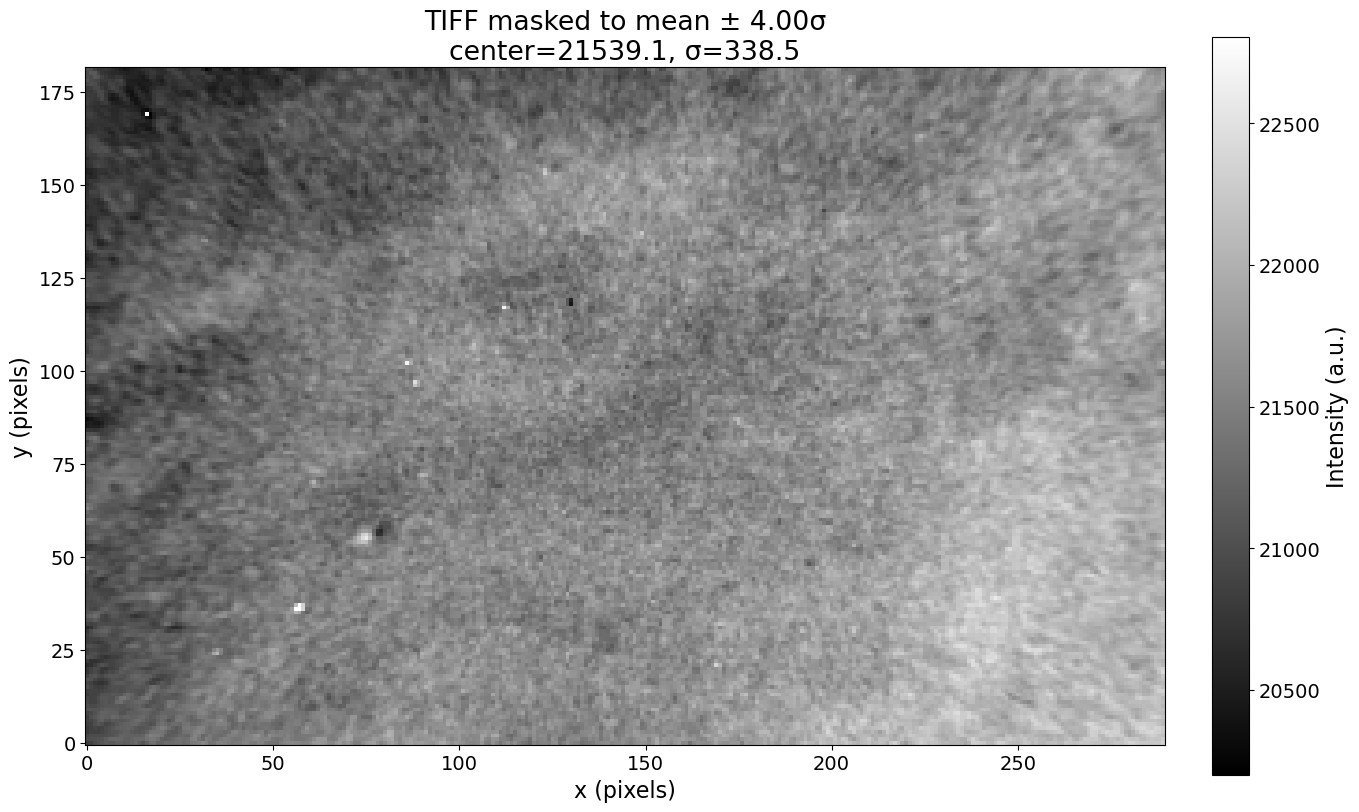

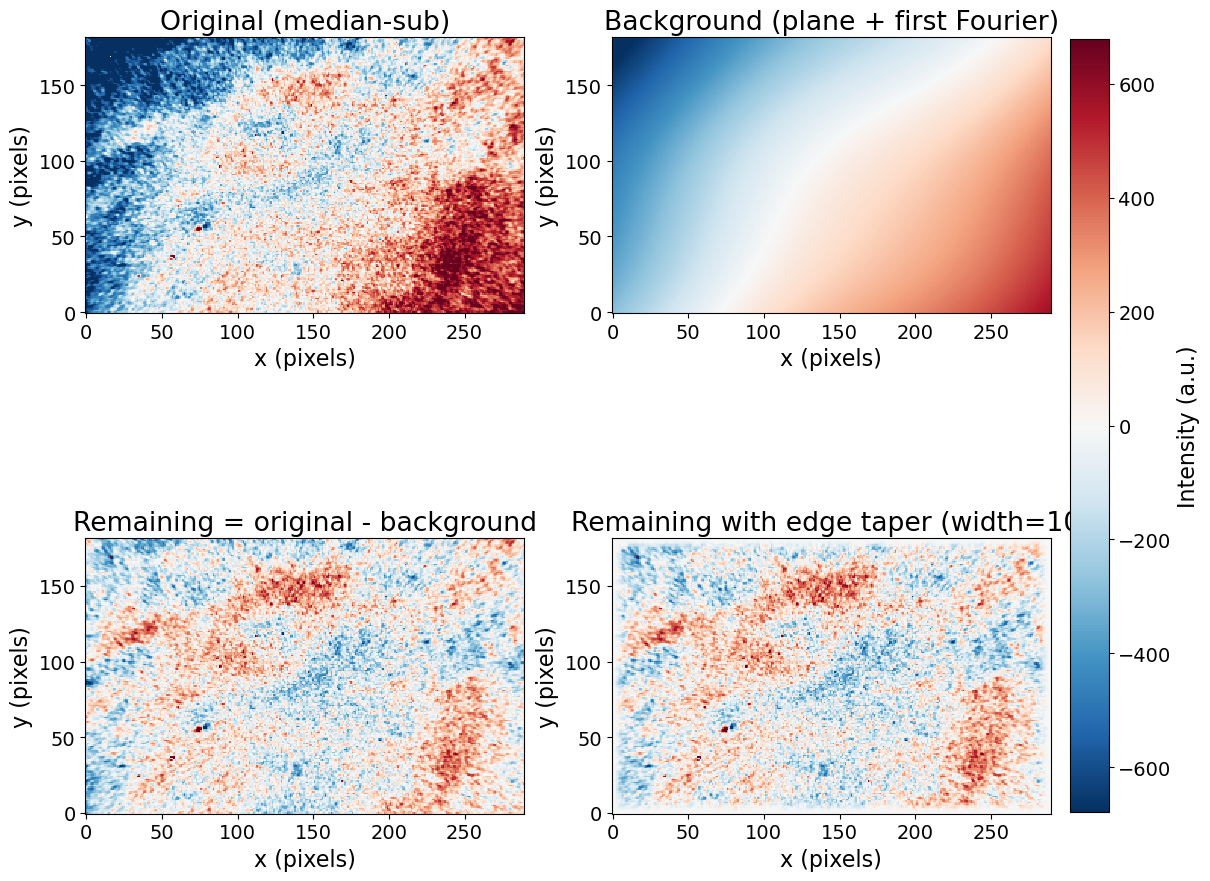

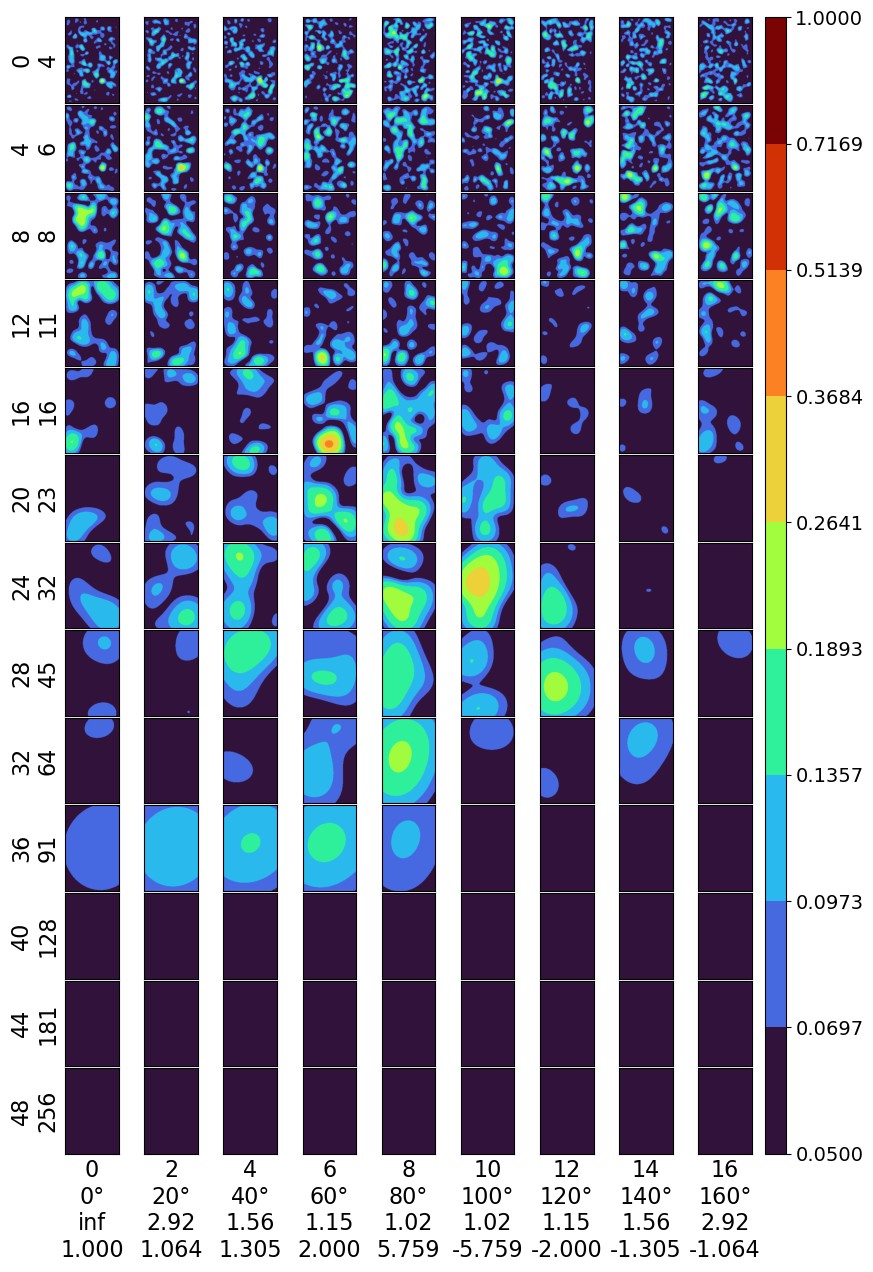

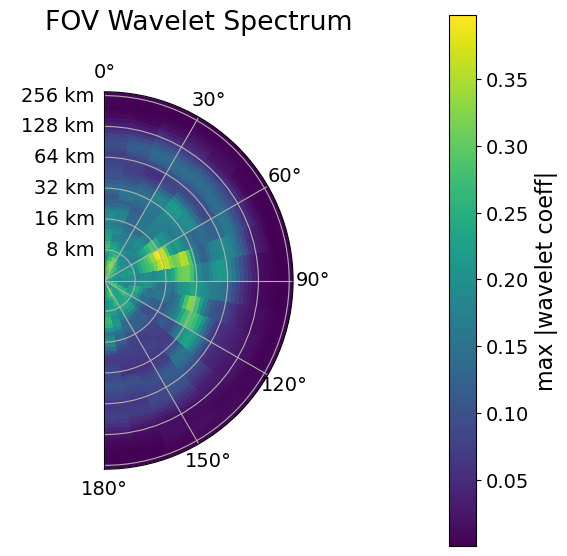

Cluster 0: amp=0.398, lamx=32.00, lamy=18.48, lam=16.00
Cluster 1: amp=0.356, lamx=72.15, lamy=26.26, lam=24.68
Cluster 2: amp=0.337, lamx=-5.99, lamy=10.37, lam=5.19
Cluster 3: amp=0.335, lamx=6.02, lamy=16.54, lam=5.66
Cluster 4: amp=0.325, lamx=-168.99, lamy=29.80, lam=29.34
Cluster 5: amp=0.312, lamx=5.69, lamy=6.79, lam=4.36
Cluster 6: amp=0.306, lamx=-25.12, lamy=4.43, lam=4.36
Cluster 7: amp=0.297, lamx=-15.17, lamy=5.52, lam=5.19
Cluster 8: amp=0.291, lamx=36.07, lamy=13.13, lam=12.34


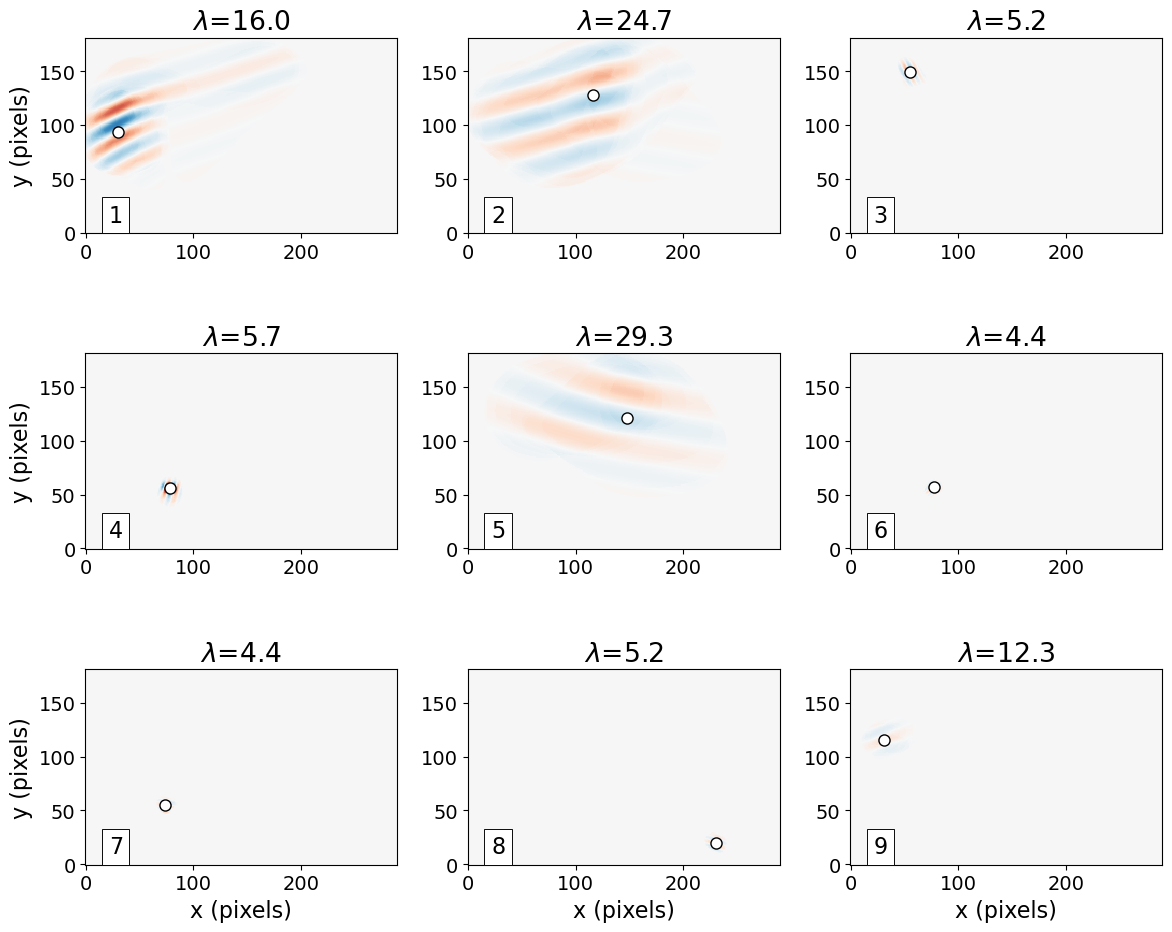

In [36]:
# Load a 16-bit TIFF, optionally mask values outside mean ± k·sigma for stats/preview,
# fill masked values for CWT, run juwavelet 2D CWT, and plot:
#   - masked/preview image
#   - original (median-sub), background (plane + first Fourier), remaining, tapered-remaining
#   - preprocessed-for-CWT
#   - FOV wavelet spectrum
#   - 9 largest wave clusters

from __future__ import annotations
from typing import Tuple, Optional

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile as tiff

from juwavelet import transform, utils, plot_utils

# --------------------------
# User params
# --------------------------
TIFF_PATH = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150\TempOH_caun1180.tif"

# ROI (pixel slices). Set to None to use full image.
X_SLICE: Optional[slice] = slice(12, 302)
Y_SLICE: Optional[slice] = slice(18, 200)

# Range filter: use mean ± k·sigma instead of fixed [6000, 10000]
APPLY_RANGE_FILTER = True
RANGE_SIGMA_FACTOR = 4   # k in mean ± k·sigma

# How to fill invalid pixels before CWT (to keep rectangular grid)
# choices: "median", "mean", "zero"
FILL_INVALID_FOR_CWT = "median"

# Preprocessing / background
REMOVE_TREND = True        # include 2D plane in "background"
STANDARDIZE = True         # z-score remaining field before CWT
GAUSS_BLUR_SIGMA = 1     # 0 disables, else e.g., 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10     # width of tapered region near each edge (in pixels)

# Wavelet params
S0 = 4
DJ = 1/8
JS = 50
JT = 18
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff_window(
    path: str,
    xsl: Optional[slice],
    ysl: Optional[slice],
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Return (x_coords, y_coords, window) where window is float32 with shape (ny, nx)."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")

    Z = np.asarray(img, dtype=np.float32)

    if ysl is None:
        ysl = slice(None, None)
    if xsl is None:
        xsl = slice(None, None)
    win = Z[ysl, xsl]

    ny, nx = win.shape
    x = np.arange(nx, dtype=float)
    y = np.arange(ny, dtype=float)

    # Clean improbable NaNs/Infs
    med = float(np.median(win))
    win = np.nan_to_num(win, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return x, y, win


def make_range_mask(Z: np.ndarray, lo: float, hi: float) -> np.ndarray:
    """True where value is inside [lo, hi]."""
    return (Z >= lo) & (Z <= hi)


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """
    Fit a 2D plane ax + by + c to Z (least squares) and return the plane.
    """
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:

      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0

    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def quicklook_pcolor(
    x1d: np.ndarray,
    y1d: np.ndarray,
    Z: np.ndarray,
    title: str,
    cmap="gray",
    vmin: float = None,
    vmax: float = None,
) -> None:
    fig, ax = plt.subplots()
    im = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Intensity (a.u.)")
    ax.set_xlabel("x (pixels)")
    ax.set_ylabel("y (pixels)")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()


def fill_invalid(Z: np.ndarray, valid_mask: np.ndarray, how: str) -> np.ndarray:
    """Fill invalid pixels to keep rectangular grid before CWT."""
    out = Z.copy()
    if valid_mask is None:
        return out
    inv = ~valid_mask
    if not np.any(inv):
        return out
    if how == "median":
        val = float(np.median(out[~inv])) if np.any(~inv) else float(np.median(out))
    elif how == "mean":
        val = float(np.mean(out[~inv])) if np.any(~inv) else float(np.mean(out))
    elif how == "zero":
        val = 0.0
    else:
        raise ValueError("FILL_INVALID_FOR_CWT must be 'median', 'mean', or 'zero'")
    out[inv] = val
    return out


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


# --------------------------
# Edge-taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """
    1D window that is ~0 at the very edges, ramps to 1 over `edge` pixels,
    and equals 1 in the interior. Hanning-like cosine ramp.
    """
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    # cosine ramp from 0 to 1
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """
    Apply a separable 2D Hanning-like taper only near the edges:
      - interior stays ~1
      - transitions smoothly to 0 at the borders over `edge` pixels.
    """
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)   # shape (ny, nx)
    return Z * W


# --------------------------
# Pipeline
# --------------------------
def run_pipeline():
    # 1) Load TIFF window
    x1d, y1d, raw = load_tiff_window(TIFF_PATH, X_SLICE, Y_SLICE)
    # Flip y to compare easier
    y1d = y1d[::-1]

    # 2) Compute mean/std and dynamic range: mean ± k·sigma
    sample = raw.ravel().astype(float)
    center = float(np.mean(sample))
    sigma = float(np.std(sample))
    k = RANGE_SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"Center (mean): {center:.2f}")
    print(f"Sigma (std):   {sigma:.2f}")
    print(f"Dynamic range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # 3) Range filter for preview
    mask = None
    if APPLY_RANGE_FILTER:
        mask = make_range_mask(raw, lo, hi)
        preview = raw.copy().astype(float)
        preview[~mask] = np.nan

        vals = preview[np.isfinite(preview)]
        if vals.size > 0:
            print(f"In-range count: {vals.size}")
            print(f"In-range min/max: {np.nanmin(vals):.2f} / {np.nanmax(vals):.2f}")
            print(f"In-range mean/std: {np.nanmean(vals):.2f} / {np.nanstd(vals):.2f}")
            p5, p50, p95 = np.nanpercentile(vals, [5, 50, 95])
            print(f"In-range percentiles 5/50/95: {p5:.2f} / {p50:.2f} / {p95:.2f}")
        else:
            print("Warning: no pixels within mean ± k·sigma")

        disp = np.clip(preview, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF masked to mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )
    else:
        disp = np.clip(raw, lo, hi)
        quicklook_pcolor(
            x1d,
            y1d,
            disp,
            f"TIFF raw, display mean ± {k:.2f}σ\ncenter={center:.1f}, σ={sigma:.1f}",
        )

    # 4) Prepare data for CWT: fill removed pixels to keep rectangular grid
    filled = fill_invalid(raw, mask, FILL_INVALID_FOR_CWT) if APPLY_RANGE_FILTER else raw

    # 5) Background separation: plane + first Fourier
    proc0 = filled.copy()
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # 6) Apply edge taper on remaining field (for CWT and plotting)
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Compute global vmin/vmax for original / background / remaining / tapered-remaining
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered

    stacked = np.concatenate([
        orig_c.ravel(),
        bg_c.ravel(),
        rem_c.ravel(),
        rem_tapered_c.ravel(),
    ])

    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 7) 4-panel background figure: original / background / remaining / tapered-remaining
    # 4-panel background figure (shared colorbar)
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10),
                                  constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()
    
    imgs_bg = [
        (orig_c, "Original (median-sub)"),
        (bg_c, "Background (plane + first Fourier)"),
        (rem_c, "Remaining = original - background"),
        (rem_tapered_c, f"Remaining with edge taper (width={TAPER_EDGE_PIXELS})"),
    ]
    
    # Draw first image, keep handle for colorbar
    im = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im = ax.pcolormesh(
            x1d,
            y1d,
            Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal")
    
    # ONE colorbar for all 4 axes
    cbar = fig_bg.colorbar(im, ax=axs_bg, orientation="vertical",
                           fraction=0.04, pad=0.02)
    cbar.set_label("Intensity (a.u.)")


    # 8) Continue preprocessing on the tapered remaining field (for CWT only)
    proc = remaining_tapered.copy()
    if STANDARDIZE:
        m = np.median(proc)
        s = np.std(proc)
        # proc = (proc - m) / s if s > 0 else (proc - m)
        proc = proc / np.std(proc) # Already subtracted median before. 
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # 9) Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=0.25, thr=0.2)

    decomposition = cwt["decomposition"]
    orig = decomposition.copy()

    # 10) Overview CWT plot
    cmap = matplotlib.cm.turbo
    norm = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap.N
    )
    fig1, _ = utils.plot_decomposition2d(cwt, redux_s=4, redux_t=2, cmap=cmap, norm=norm)

    # 11) FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")

    # 12) Component panels: 9 largest clusters
    fig2, axs = plt.subplots(3, 3, figsize=(12, 10))
    axes_flat = axs.flatten()

    opts_img = {"cmap": "RdBu_r", "vmin": -.8, "vmax": .8, "rasterized": True}

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes_flat:
            ax.set_title("no clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(9, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes_flat, biggest):
            # Reconstruct this cluster only
            decomposition[:] = orig
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)  # (nx, ny)

            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]            # (s_idx, t_idx, ...)
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2
            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                #rf"$\lambda_x$={_fmt(lamx)}  "
                #rf"$\lambda_y$={_fmt(lamy)}  "
                rf"$\lambda$={_fmt(lam)}"
            )
            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img)

            # Mark peak location
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(), decomposition[0, 0].shape
            )
            ax.plot(
                x1d[max_idx[0]],
                y1d[max_idx[1]],
                "o", color="w", mec="k", ms=8,
            )

            ax.set_aspect("equal", adjustable="box")

            print(
                f"Cluster {kcl}: amp={amps[kcl]:.3f}, "
                f"lamx={lamx:.2f}, lamy={lamy:.2f}, "
                f"lam={'inf' if not np.isfinite(lam) else f'{lam:.2f}'}"
            )

        # If fewer than 9 clusters, hide the remaining axes
        for ax in axes_flat[n_show:]:
            ax.set_title("no cluster")
            ax.axis("off")

    # Axis labels (pixels)
    for ax in axs[2, :]:
        ax.set_xlabel("x (pixels)")
    for ax in axs[:, 0]:
        ax.set_ylabel("y (pixels)")

    # Number tags (1–9)
    number_box = {
        "boxstyle": "square",
        "lw": 0.67,
        "facecolor": "white",
        "edgecolor": "black",
    }
    for i, ax in enumerate(axes_flat, start=1):
        ax.text(
            0.12,
            0.15,
            str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
            #weight="bold",
        )

    fig2.tight_layout()

    # Show both the decomposition overview and cluster figure
    plt.show(fig_bg)
    plt.show(fig1)
    plt.show(fig2)


# --------------------------
# Run
# --------------------------
if __name__ == "__main__":
    run_pipeline()


Loaded 11 frames, shape = (11, 256, 320)
center: 21161.81, sigma: 3918.61
use range: [19202.50, 23121.11]


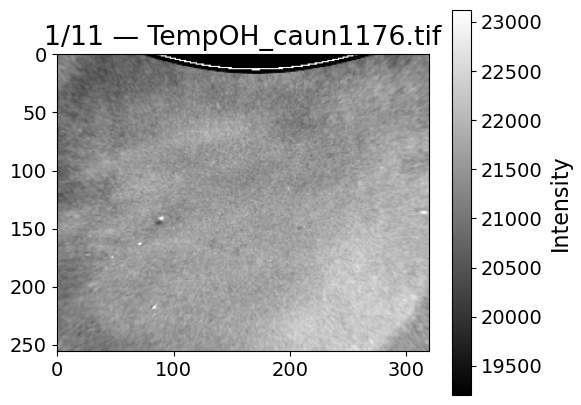

In [42]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------
# User settings
# --------------------
FOLDER = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Nov7th1150"
FACTOR = 0.5  # center ± FACTOR * sigma range


# Load all TIFFs into memory
files = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files:
    raise FileNotFoundError("No TIFFs found in folder.")

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)   # shape: (N, ny, nx)

print(f"Loaded {len(files)} frames, shape = {data.shape}")

# Compute global stats for display
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"center: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot movie animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

title = ax.set_title(os.path.basename(files[0]))
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    title.set_text(f"{i+1}/{len(files)} — {os.path.basename(files[i])}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())


Loaded 10 frames, shape = (10, 256, 320)
center: 8034.57, sigma: 3213.27
use range: [6427.94, 9641.21]


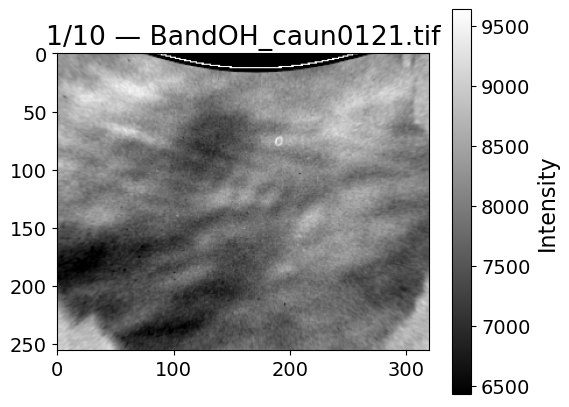

In [44]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --------------------
# User settings
# --------------------
FOLDER = r"C:\Users\domin\juwavelet\examples\Waves For Anh\Sep14th527"
FACTOR = 0.5  # center ± FACTOR * sigma range


# Load all TIFFs into memory
files = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files:
    raise FileNotFoundError("No TIFFs found in folder.")

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)   # shape: (N, ny, nx)

print(f"Loaded {len(files)} frames, shape = {data.shape}")

# Compute global stats for display
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"center: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot movie animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

title = ax.set_title(os.path.basename(files[0]))
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    title.set_text(f"{i+1}/{len(files)} — {os.path.basename(files[i])}")
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())
